## Environment Setup

In [6]:
import subprocess, sys
PKGS = ['pyspark','matplotlib','seaborn','networkx','pandas','numpy',
        'scipy','wordcloud','openpyxl']
for p in PKGS:
    subprocess.check_call([sys.executable,'-m','pip','install',p,'-q'])
print('All packages ready.')

All packages ready.


In [7]:
import os, time, warnings, math
from itertools import combinations
from collections import defaultdict
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import networkx as nx
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
try:
    from wordcloud import WordCloud
    HAS_WC = True
except ImportError:
    HAS_WC = False

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType

DARK_BG   = '#0d1117'
CARD_BG   = '#161b22'
ACCENT1   = '#f9c74f'
ACCENT2   = '#90e0ef'
ACCENT3   = '#f94144'
ACCENT4   = '#43aa8b'
ACCENT5   = '#c77dff'
PAL       = [ACCENT1, ACCENT2, ACCENT3, ACCENT4, ACCENT5,
             '#f77f00','#2d6a4f','#e9c46a','#264653','#e76f51']

plt.rcParams.update({
    'figure.facecolor' : DARK_BG,
    'axes.facecolor'   : CARD_BG,
    'axes.edgecolor'   : '#30363d',
    'axes.labelcolor'  : '#c9d1d9',
    'axes.titlecolor'  : '#f0f6fc',
    'axes.grid'        : True,
    'grid.color'       : '#21262d',
    'grid.linewidth'   : 0.8,
    'xtick.color'      : '#8b949e',
    'ytick.color'      : '#8b949e',
    'text.color'       : '#c9d1d9',
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 10.5,
    'legend.facecolor' : '#21262d',
    'legend.edgecolor' : '#30363d',
    'figure.dpi'       : 120,
})


spark = (
    SparkSession.builder
    .appName('MBA_APriori_PCY')
    .config('spark.driver.memory','4g')
    .config('spark.sql.shuffle.partitions','8')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('ERROR')
print(f'Spark {spark.version} ready.')

Spark 4.1.1 ready.


## Data Loading

In [8]:
import os

os.makedirs('figures', exist_ok=True)
os.makedirs('data', exist_ok=True)


def generate_synthetic(n_transactions=6000, seed=42):
    rng = np.random.default_rng(seed)

    categories = {
        'dairy': ['whole milk', 'butter', 'cream cheese', 'yogurt', 'whipped cream',
                  'sour cream', 'condensed milk', 'curd'],
        'produce': ['other vegetables', 'root vegetables', 'tropical fruit', 'citrus fruit',
                    'pip fruit', 'onions', 'berries', 'herbs', 'specialty vegetables'],
        'bakery': ['rolls/buns', 'brown bread', 'pastry', 'waffles', 'cake bar', 'cookies'],
        'beverages': ['soda', 'bottled water', 'fruit juice', 'bottled beer',
                      'canned beer', 'coffee', 'tea', 'misc beverages'],
        'meat': ['sausage', 'pork', 'beef', 'chicken', 'frankfurter', 'ham', 'turkey'],
        'snacks': ['chocolate', 'nuts', 'candy bars', 'specialty bar', 'chips', 'popcorn'],
        'household': ['dish cleaner', 'detergent', 'fabric softener', 'toilet cleaner',
                      'kitchen towels', 'napkins', 'light bulbs', 'batteries'],
        'pantry': ['pasta', 'rice', 'salt', 'sugar', 'oil', 'margarine', 'jam', 'ketchup'],
    }
    all_items = [item for cat in categories.values() for item in cat]
    cat_of = {item: cat for cat, items in categories.items() for item in items}

    rows, dates = [], []
    import datetime
    base_date = datetime.date(2023, 1, 1)

    for tid in range(n_transactions):
        basket_size = int(rng.choice([2, 3, 4, 5, 6, 7, 8], p=[0.05, 0.15, 0.25, 0.25, 0.15, 0.10, 0.05]))
        # Pick a seed category; sample mostly within it
        seed_cat = rng.choice(list(categories.keys()))
        seed_items = categories[seed_cat]
        n_from_cat = min(basket_size, rng.integers(1, len(seed_items) + 1))
        basket = set(rng.choice(seed_items, size=n_from_cat, replace=False).tolist())
        # Fill remaining slots from global pool
        remaining = [i for i in all_items if i not in basket]
        extra_n = max(0, basket_size - len(basket))
        if extra_n > 0 and remaining:
            basket.update(rng.choice(remaining,
                                     size=min(extra_n, len(remaining)),
                                     replace=False).tolist())
        day_offset = int(rng.integers(0, 365))
        date_str = (base_date + datetime.timedelta(days=day_offset)).isoformat()
        for item in basket:
            rows.append({'transaction_id': str(tid), 'item': item,
                         'date': date_str, 'category': cat_of[item]})

    return pd.DataFrame(rows)


# Load data
GROCERIES_PATH = 'data/Groceries_dataset.csv'
ONLINE_RETAIL_PATH = 'data/Online Retail.xlsx'

if os.path.exists(GROCERIES_PATH):
    raw_pdf = pd.read_csv(GROCERIES_PATH)
    raw_pdf.columns = ['transaction_id', 'date', 'item']
    raw_pdf['transaction_id'] = raw_pdf['transaction_id'].astype(str)
    raw_pdf['item'] = raw_pdf['item'].str.strip().str.lower()
    raw_pdf['date'] = pd.to_datetime(raw_pdf['date'], errors='coerce')
    raw_pdf['category'] = 'unknown'
    DATASET_NAME = 'Groceries (Kaggle)'
elif os.path.exists(ONLINE_RETAIL_PATH):
    tmp = pd.read_excel(ONLINE_RETAIL_PATH, engine='openpyxl')
    tmp = tmp[['InvoiceNo', 'InvoiceDate', 'Description']].dropna()
    tmp.columns = ['transaction_id', 'date', 'item']
    tmp = tmp[~tmp['transaction_id'].astype(str).str.startswith('C')]
    raw_pdf = tmp.copy()
    raw_pdf['item'] = raw_pdf['item'].str.strip().str.lower()
    raw_pdf['transaction_id'] = raw_pdf['transaction_id'].astype(str)
    raw_pdf['date'] = pd.to_datetime(raw_pdf['date'], errors='coerce')
    raw_pdf['category'] = 'unknown'
    DATASET_NAME = 'Online Retail (UCI)'
else:
    print('No dataset found — generating synthetic data...')
    raw_pdf = generate_synthetic(n_transactions=6000)
    raw_pdf['date'] = pd.to_datetime(raw_pdf['date'])
    DATASET_NAME = 'Synthetic Grocery'

raw_pdf = raw_pdf.dropna(subset=['item'])
raw_pdf = raw_pdf[raw_pdf['item'].str.strip() != '']

# Spark DF
transactions_df = spark.createDataFrame(
    raw_pdf[['transaction_id', 'item']].astype(str)
).cache()

n_transactions = transactions_df.select('transaction_id').distinct().count()
n_unique_items = transactions_df.select('item').distinct().count()
basket_sizes_pdf = (transactions_df.groupBy('transaction_id').count().toPandas())
avg_basket = basket_sizes_pdf['count'].mean()

print(f'Dataset      : {DATASET_NAME}')
print(f'Transactions : {n_transactions:,}')
print(f'Unique items : {n_unique_items:,}')
print(f'Avg basket   : {avg_basket:.2f}')

Dataset      : Groceries (Kaggle)
Transactions : 3,898
Unique items : 167
Avg basket   : 9.94


### 1.1 Dataset EDA Dashboard

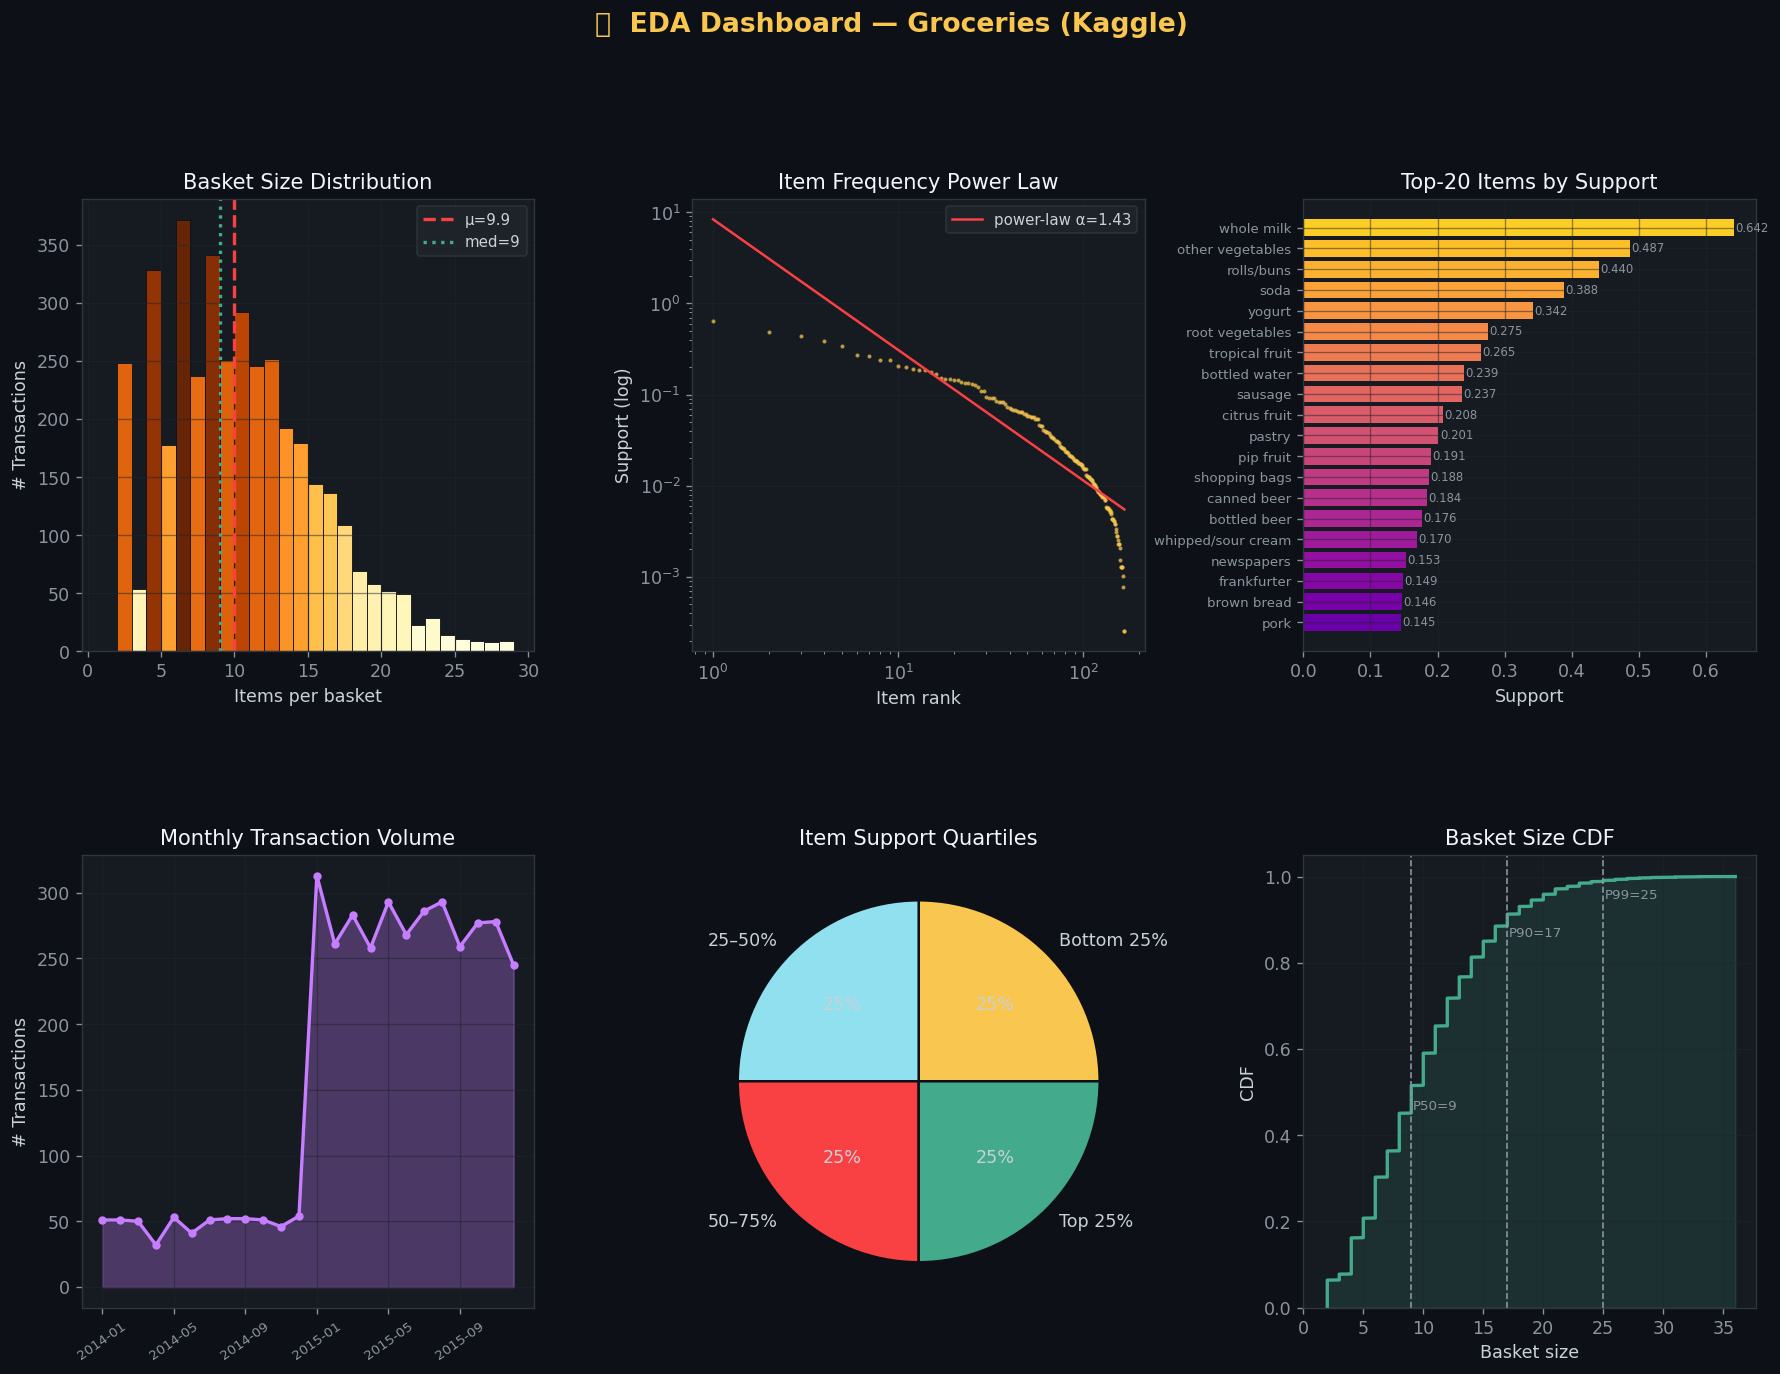

Saved: figures/fig1_eda_dashboard.png


In [9]:
item_freq = (
    transactions_df.groupBy('item').count()
    .orderBy(F.desc('count')).toPandas()
)
item_freq['support'] = item_freq['count'] / n_transactions

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle(f'📊  EDA Dashboard — {DATASET_NAME}',
             fontsize=16, fontweight='bold', color=ACCENT1, y=1.01)

# ── (A) Basket size distribution ──
ax = fig.add_subplot(gs[0, 0])
bs = basket_sizes_pdf['count']
bins = range(1, min(int(bs.max()) + 2, 30))
n_hist, bin_edges, patches = ax.hist(bs, bins=bins, color=ACCENT2, edgecolor=DARK_BG, linewidth=0.5)
# Colour bars by frequency
norm = plt.Normalize(n_hist.min(), n_hist.max())
for val, patch in zip(n_hist, patches):
    patch.set_facecolor(plt.cm.YlOrBr(norm(val)))
ax.axvline(bs.mean(), color=ACCENT3, lw=2, ls='--', label=f'μ={bs.mean():.1f}')
ax.axvline(bs.median(), color=ACCENT4, lw=2, ls=':', label=f'med={bs.median():.0f}')
ax.set_xlabel('Items per basket');
ax.set_ylabel('# Transactions')
ax.set_title('Basket Size Distribution');
ax.legend(fontsize=9)

# ── (B) Item frequency (log scale) ──
ax = fig.add_subplot(gs[0, 1])
ranks = np.arange(1, len(item_freq) + 1)
ax.loglog(ranks, item_freq['support'].values, '.', color=ACCENT1, alpha=0.6, ms=3)
# Fit power-law line
log_r, log_s = np.log(ranks), np.log(item_freq['support'].values + 1e-9)
slope, intercept = np.polyfit(log_r, log_s, 1)
ax.loglog(ranks, np.exp(intercept) * ranks ** slope, '-', color=ACCENT3, lw=1.5,
          label=f'power-law α={-slope:.2f}')
ax.set_xlabel('Item rank');
ax.set_ylabel('Support (log)')
ax.set_title('Item Frequency Power Law');
ax.legend(fontsize=9)

# ── (C) Top-20 items horizontal bar ──
ax = fig.add_subplot(gs[0, 2])
top20 = item_freq.head(20).iloc[::-1]
colors_bar = plt.cm.plasma(np.linspace(0.2, 0.9, 20))
bars = ax.barh(top20['item'], top20['support'], color=colors_bar)
ax.set_xlabel('Support');
ax.set_title('Top-20 Items by Support')
ax.yaxis.set_tick_params(labelsize=8)
for bar, val in zip(bars, top20['support']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=7, color='#8b949e')

# ── (D) Transaction volume over time ──
ax = fig.add_subplot(gs[1, 0])
if 'date' in raw_pdf.columns and raw_pdf['date'].dtype != object:
    monthly = (raw_pdf.drop_duplicates('transaction_id')
               .assign(month=raw_pdf['date'].dt.to_period('M'))
               .groupby('month').size().reset_index(name='count'))
    monthly['month_str'] = monthly['month'].astype(str)
    ax.fill_between(range(len(monthly)), monthly['count'], alpha=0.3, color=ACCENT5)
    ax.plot(range(len(monthly)), monthly['count'], color=ACCENT5, lw=2, marker='o', ms=4)
    step = max(1, len(monthly) // 6)
    ax.set_xticks(range(0, len(monthly), step))
    ax.set_xticklabels(monthly['month_str'].iloc[::step], rotation=35, fontsize=8)
    ax.set_title('Monthly Transaction Volume')
else:
    ax.text(0.5, 0.5, 'No date column available', ha='center', va='center',
            transform=ax.transAxes, color='#8b949e')
    ax.set_title('Monthly Volume')
ax.set_ylabel('# Transactions')

# ── (E) Category breakdown (if available) ──
ax = fig.add_subplot(gs[1, 1])
if 'category' in raw_pdf.columns and raw_pdf['category'].nunique() > 1:
    cat_counts = raw_pdf.groupby('category')['item'].count().sort_values(ascending=False)
    wedges, texts, autotexts = ax.pie(
        cat_counts.values, labels=cat_counts.index,
        autopct='%1.1f%%', colors=PAL[:len(cat_counts)],
        pctdistance=0.82, startangle=90,
        wedgeprops={'linewidth': 1.5, 'edgecolor': DARK_BG}
    )
    for t in texts: t.set_fontsize(8)
    for at in autotexts: at.set_fontsize(7); at.set_color('white')
    ax.set_title('Item Category Distribution')
else:
    # Quantile breakdown of support
    q_labels = ['Bottom 25%', '25–50%', '50–75%', 'Top 25%']
    q_counts = [len(item_freq) // 4] * 4
    ax.pie(q_counts, labels=q_labels, colors=PAL[:4], autopct='%1.0f%%',
           wedgeprops={'linewidth': 1.5, 'edgecolor': DARK_BG})
    ax.set_title('Item Support Quartiles')

# ── (F) Basket size CDF ──
ax = fig.add_subplot(gs[1, 2])
sorted_bs = np.sort(bs.values)
cdf = np.arange(1, len(sorted_bs) + 1) / len(sorted_bs)
ax.plot(sorted_bs, cdf, color=ACCENT4, lw=2)
ax.fill_between(sorted_bs, cdf, alpha=0.15, color=ACCENT4)
for pct in [0.5, 0.9, 0.99]:
    xval = sorted_bs[np.searchsorted(cdf, pct)]
    ax.axvline(xval, color='#8b949e', lw=1, ls='--')
    ax.text(xval + 0.1, pct - 0.04, f'P{int(pct * 100)}={xval}',
            color='#8b949e', fontsize=8)
ax.set_xlabel('Basket size');
ax.set_ylabel('CDF')
ax.set_title('Basket Size CDF')
ax.set_xlim(left=0);
ax.set_ylim(0, 1.05)

plt.savefig('figures/fig1_eda_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print('Saved: figures/fig1_eda_dashboard.png')

### 1.2 Item Co-occurrence Heatmap (Top-25 Items)

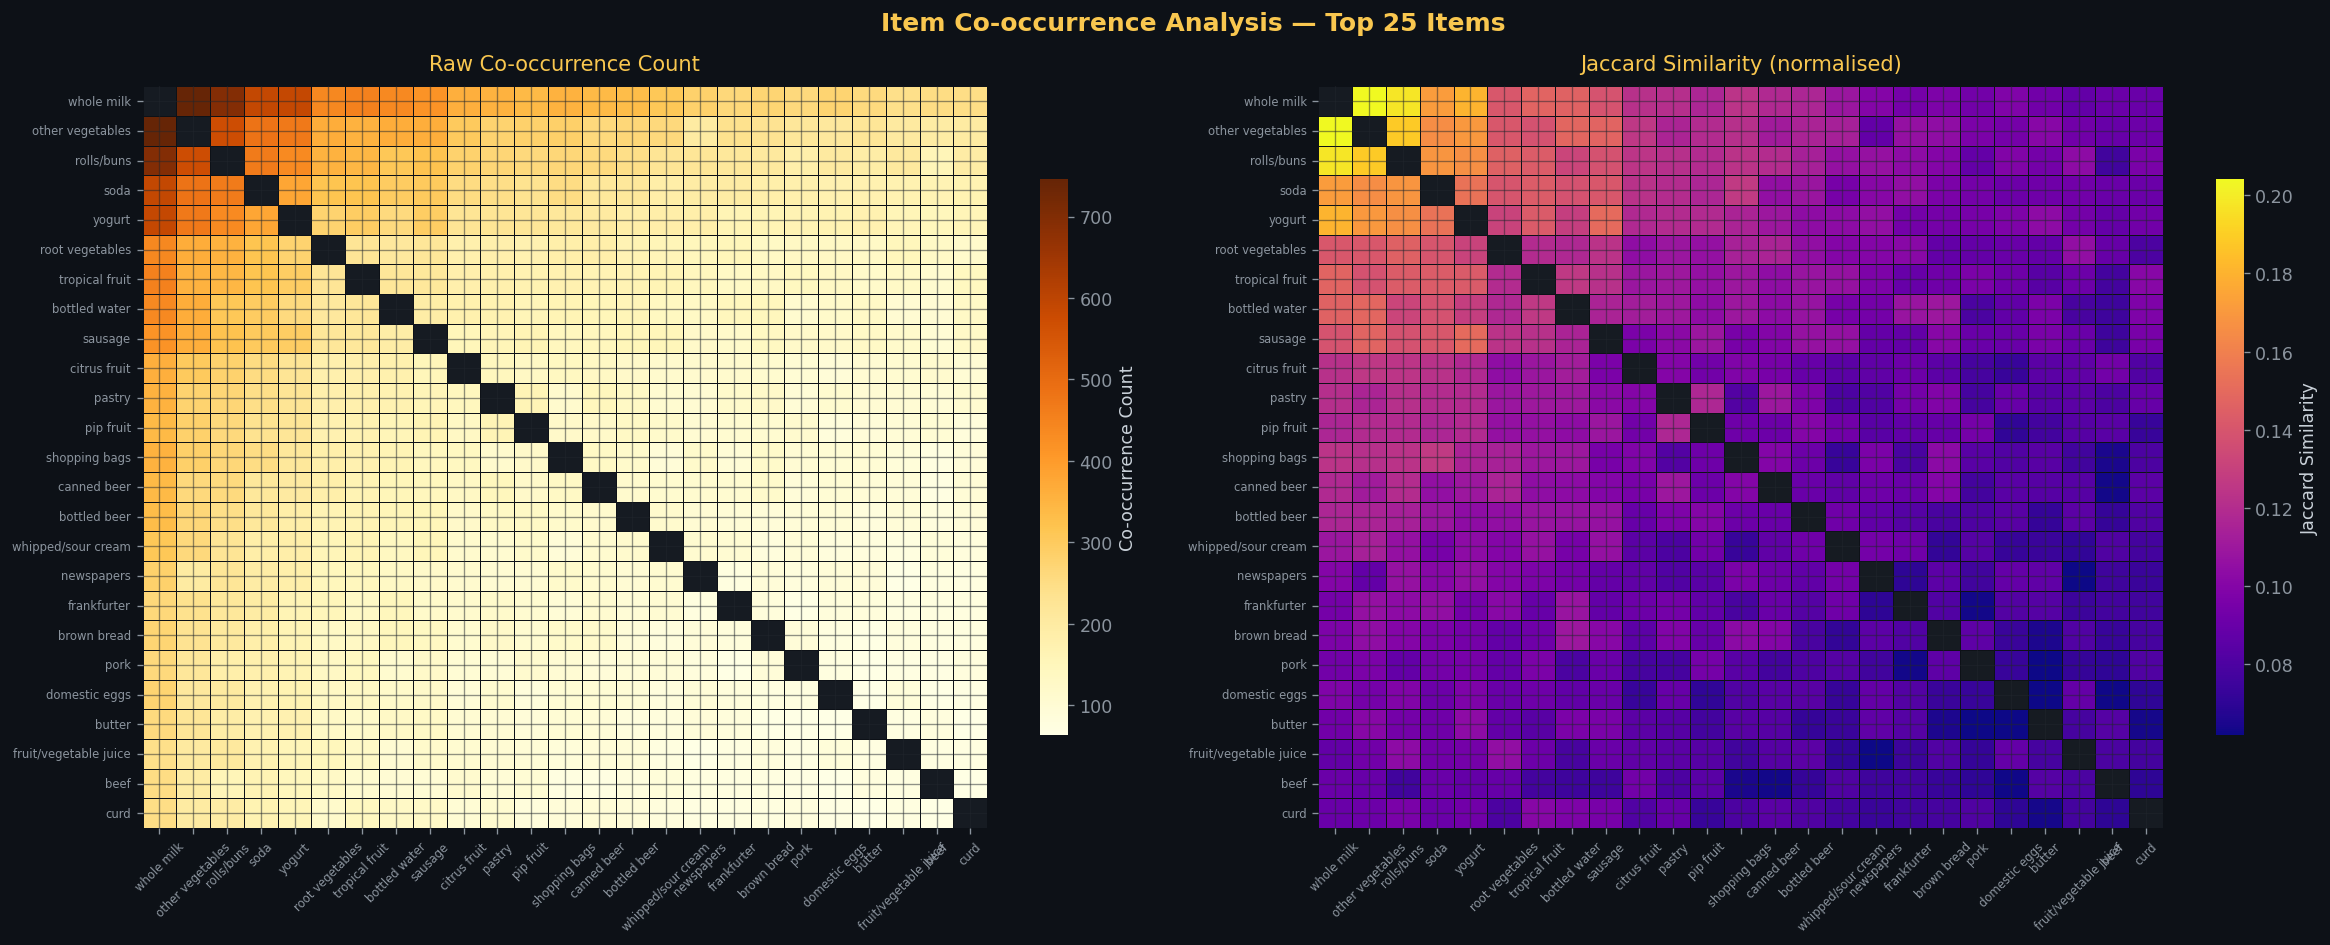

Saved: figures/fig2_cooccurrence_heatmap.png


In [10]:
TOP_ITEMS = item_freq['item'].head(25).tolist()

# Build baskets as Python dicts partitioned ─ collect to driver
baskets_rdd = (
    transactions_df
    .groupBy('transaction_id')
    .agg(F.collect_list('item').alias('items'))
    .select('items')
    .rdd.map(lambda r: frozenset(r['items']))
).cache()


# Co-occurrence matrix via RDD flatMap
def cooc_pairs(basket):
    top_set = set(TOP_ITEMS)
    items_in = [i for i in basket if i in top_set]
    for a, b in combinations(sorted(items_in), 2):
        yield ((a, b), 1)


cooc_counts = (
    baskets_rdd.flatMap(cooc_pairs)
    .reduceByKey(lambda x, y: x + y)
    .collect()
)

# Build symmetric matrix
idx = {item: i for i, item in enumerate(TOP_ITEMS)}
n = len(TOP_ITEMS)
M = np.zeros((n, n))
for (a, b), cnt in cooc_counts:
    if a in idx and b in idx:
        M[idx[a], idx[b]] = cnt
        M[idx[b], idx[a]] = cnt
np.fill_diagonal(M, 0)

# Jaccard-normalise
item_cnts_vec = np.array([item_freq.set_index('item').loc[i, 'count']
                          if i in item_freq['item'].values else 1
                          for i in TOP_ITEMS], dtype=float)
J = np.zeros_like(M)
for i in range(n):
    for j in range(n):
        union = item_cnts_vec[i] + item_cnts_vec[j] - M[i, j]
        J[i, j] = M[i, j] / union if union > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Item Co-occurrence Analysis — Top 25 Items',
             fontsize=15, fontweight='bold', color=ACCENT1)

# Raw count heatmap
ax = axes[0]
mask = np.eye(n, dtype=bool)
sns.heatmap(M, xticklabels=TOP_ITEMS, yticklabels=TOP_ITEMS,
            cmap='YlOrBr', ax=ax, mask=mask, linewidths=0.3,
            linecolor=DARK_BG, cbar_kws={'shrink': 0.75, 'label': 'Co-occurrence Count'})
ax.set_title('Raw Co-occurrence Count', color=ACCENT1, pad=10)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)

# Jaccard similarity heatmap
ax = axes[1]
sns.heatmap(J, xticklabels=TOP_ITEMS, yticklabels=TOP_ITEMS,
            cmap='plasma', ax=ax, mask=mask, linewidths=0.3,
            linecolor=DARK_BG, cbar_kws={'shrink': 0.75, 'label': 'Jaccard Similarity'})
ax.set_title('Jaccard Similarity (normalised)', color=ACCENT1, pad=10)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.tight_layout()
plt.savefig('figures/fig2_cooccurrence_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print('Saved: figures/fig2_cooccurrence_heatmap.png')

## A-Priori Algorithm (Spark RDD)

In [11]:
class APrioriSpark:
    """
    Distributed A-Priori with full per-pass statistics.
    Implements the monotonicity-based pruning from L2 lecture material.
    """

    def __init__(self, min_support: int, max_k: int = 5):
        self.min_support = min_support
        self.max_k = max_k
        self.frequent_itemsets: dict[int, dict[frozenset, int]] = {}
        self.stats: list[dict] = []  # per-pass stats
        self.timing: dict[int, float] = {}

    def _pass1(self, rdd):
        t0 = time.time()
        raw = (
            rdd.flatMap(lambda b: [(i, 1) for i in b])
            .reduceByKey(lambda a, b: a + b)
        )
        all1 = raw.count()
        freq1 = {frozenset([i]): c for i, c in raw.filter(lambda x: x[1] >= self.min_support).collect()}
        self.timing[1] = time.time() - t0
        self.stats.append({'k': 1, 'candidates': all1, 'frequent': len(freq1),
                           'pruned': all1 - len(freq1), 'time': self.timing[1]})
        return freq1

    @staticmethod
    def _gen_candidates(prev: dict[frozenset, int], k: int) -> list[frozenset]:
        all_items = frozenset().union(*prev.keys())
        candidates = set()
        for iset in prev:
            for item in all_items:
                if item not in iset:
                    c = iset | frozenset([item])
                    if len(c) == k: candidates.add(c)
        pruned = [c for c in candidates
                  if all(frozenset(s) in prev for s in combinations(c, k - 1))]
        return pruned

    def _count_candidates(self, rdd, candidates):
        bc = rdd.context.broadcast(candidates)

        def emit(basket):
            s = set(basket)
            for c in bc.value:
                if c.issubset(s): yield (c, 1)

        result = dict(
            rdd.flatMap(emit).reduceByKey(lambda a, b: a + b)
            .filter(lambda x: x[1] >= self.min_support).collect()
        )
        bc.unpersist()
        return result

    def fit(self, rdd):
        print(f'\n  A-Priori | min_support={self.min_support}')
        print(f'  {"k":>4}  {"candidates":>12}  {"frequent":>10}  {"pruned%":>8}  {"time":>7}')
        print('  ' + '─' * 52)

        L = self._pass1(rdd)
        self.frequent_itemsets[1] = L
        s = self.stats[-1]
        print(f'  {1:>4}  {s["candidates"]:>12,}  {s["frequent"]:>10,}  '
              f'{100 * s["pruned"] / max(s["candidates"], 1):>7.1f}%  {s["time"]:>6.2f}s')

        for k in range(2, self.max_k + 1):
            cands = self._gen_candidates(self.frequent_itemsets[k - 1], k)
            if not cands: break
            t0 = time.time()
            Lk = self._count_candidates(rdd, cands)
            self.timing[k] = time.time() - t0
            self.stats.append({'k': k, 'candidates': len(cands), 'frequent': len(Lk),
                               'pruned': len(cands) - len(Lk), 'time': self.timing[k]})
            s = self.stats[-1]
            print(f'  {k:>4}  {s["candidates"]:>12,}  {s["frequent"]:>10,}  '
                  f'{100 * s["pruned"] / max(s["candidates"], 1):>7.1f}%  {s["time"]:>6.2f}s')
            if not Lk: break
            self.frequent_itemsets[k] = Lk

        total = sum(len(v) for v in self.frequent_itemsets.values())
        print(f'  {"─" * 52}')
        print(f'  Total frequent itemsets: {total:,}')
        return self

    def to_dataframe(self):
        rows = []
        for k, d in self.frequent_itemsets.items():
            for iset, cnt in d.items():
                rows.append({'size': k, 'itemset': iset, 'support_count': cnt})
        df = pd.DataFrame(rows)
        df['support'] = df['support_count'] / n_transactions
        return df.sort_values('support_count', ascending=False).reset_index(drop=True)


# ── Run A-Priori ─────────────────────────────────────────────────────────────
MIN_SUPPORT_FRAC = 0.025
MIN_SUPPORT = max(2, int(MIN_SUPPORT_FRAC * n_transactions))
MAX_K = 4

apriori = APrioriSpark(min_support=MIN_SUPPORT, max_k=MAX_K)
apriori.fit(baskets_rdd)
fi_df = apriori.to_dataframe()
print(f'\nDataFrame shape: {fi_df.shape}')


  A-Priori | min_support=97
     k    candidates    frequent   pruned%     time
  ────────────────────────────────────────────────────
     1           167          78     53.3%    0.41s
     2         3,003         355     88.2%    0.69s
     3         1,507         148     90.2%    0.50s
     4            73           4     94.5%    0.31s
  ────────────────────────────────────────────────────
  Total frequent itemsets: 585

DataFrame shape: (585, 4)


## PCY Algorithm (Hash-Based Bucket Filtering)

In [12]:
class PCYSpark:
    """
    Park-Chen-Yu (PCY) algorithm.
    Pass 1: count singletons AND hash every pair into a bucket array.
    Pass 2: count only candidate pairs whose bucket count >= min_support (bitmap filter).
    Pass k≥3: falls back to A-Priori-style candidate pruning.

    The bucket trick dramatically reduces Pass-2 candidate pairs compared to vanilla A-Priori.
    """

    def __init__(self, min_support: int, n_buckets: int = 100_003, max_k: int = 4):
        self.min_support = min_support
        self.n_buckets = n_buckets
        self.max_k = max_k
        self.frequent_itemsets: dict[int, dict[frozenset, int]] = {}
        self.stats: list[dict] = []
        self.timing: dict[int, float] = {}
        self.n_buckets_above_threshold: int = 0

    def _hash_pair(self, a: str, b: str) -> int:
        return (hash(a) * 2654435761 + hash(b) * 40503) % self.n_buckets

    def _pass1(self, rdd):
        """Count singletons + bucket-hash all pairs."""
        t0 = time.time()
        n_b = self.n_buckets

        def pass1_mapper(basket):
            items = sorted(basket)
            for item in items:
                yield (f'ITEM::{item}', 1)
            for a, b in combinations(items, 2):
                bucket = (hash(a) * 2654435761 + hash(b) * 40503) % n_b
                yield (f'BUCKET::{bucket}', 1)

        counts = rdd.flatMap(pass1_mapper).reduceByKey(lambda x, y: x + y).collect()

        item_counts, bucket_counts = {}, {}
        for key, cnt in counts:
            if key.startswith('ITEM::'):
                item_counts[key[6:]] = cnt
            else:
                bucket_counts[int(key[8:])] = cnt

        # Frequent singletons
        L1 = {frozenset([i]): c for i, c in item_counts.items()
              if c >= self.min_support}
        # Bitmap: True if bucket count >= min_support
        bitmap = np.zeros(n_b, dtype=bool)
        for b_idx, b_cnt in bucket_counts.items():
            if b_cnt >= self.min_support:
                bitmap[b_idx] = True
        self.bitmap = bitmap
        self.n_buckets_above_threshold = int(bitmap.sum())
        self.timing[1] = time.time() - t0

        all1 = len(item_counts)
        self.stats.append({'k': 1, 'candidates': all1, 'frequent': len(L1),
                           'pruned': all1 - len(L1), 'time': self.timing[1]})
        return L1

    def _pass2(self, rdd, L1: dict[frozenset, int]):
        """Count pairs that are: (a) both items frequent AND (b) hash to a bitmap-set bucket."""
        t0 = time.time()
        freq_items = frozenset(list(i)[0] for i in L1)
        bitmap = self.bitmap
        n_b = self.n_buckets

        # Generate and count PCY-filtered candidates
        raw_candidates = set()
        for a, b in combinations(sorted(freq_items), 2):
            bucket = (hash(a) * 2654435761 + hash(b) * 40503) % n_b
            if bitmap[bucket]:
                raw_candidates.add(frozenset([a, b]))

        # A-Priori candidates (for comparison metric)
        apriori_candidates = list(combinations(sorted(freq_items), 2))
        self.pcy_savings_pct = 100 * (1 - len(raw_candidates) / max(len(apriori_candidates), 1))

        bc = rdd.context.broadcast(list(raw_candidates))

        def emit(basket):
            s = set(basket)
            for c in bc.value:
                if c.issubset(s): yield (c, 1)

        L2 = dict(
            rdd.flatMap(emit).reduceByKey(lambda x, y: x + y)
            .filter(lambda x: x[1] >= self.min_support).collect()
        )
        bc.unpersist()
        self.timing[2] = time.time() - t0

        self.stats.append({'k': 2,
                           'candidates': len(raw_candidates),
                           'frequent': len(L2),
                           'pruned': len(raw_candidates) - len(L2),
                           'time': self.timing[2],
                           'pcy_filtered': len(apriori_candidates) - len(raw_candidates)})
        return L2

    def _gen_candidates_apriori(self, prev, k):
        all_items = frozenset().union(*prev.keys())
        candidates = set()
        for iset in prev:
            for item in all_items:
                if item not in iset:
                    c = iset | frozenset([item])
                    if len(c) == k: candidates.add(c)
        return [c for c in candidates
                if all(frozenset(s) in prev for s in combinations(c, k - 1))]

    def _count(self, rdd, cands):
        bc = rdd.context.broadcast(cands)

        def emit(basket):
            s = set(basket)
            for c in bc.value:
                if c.issubset(s): yield (c, 1)

        result = dict(
            rdd.flatMap(emit).reduceByKey(lambda x, y: x + y)
            .filter(lambda x: x[1] >= self.min_support).collect()
        )
        bc.unpersist()
        return result

    def fit(self, rdd):
        print(f'\n  PCY | min_support={self.min_support} | buckets={self.n_buckets:,}')
        print(f'  {"k":>4}  {"candidates":>12}  {"frequent":>10}  {"pruned%":>8}  {"time":>7}')
        print('  ' + '─' * 52)

        L1 = self._pass1(rdd)
        self.frequent_itemsets[1] = L1
        s = self.stats[-1]
        print(f'  {1:>4}  {s["candidates"]:>12,}  {s["frequent"]:>10,}  '
              f'{100 * s["pruned"] / max(s["candidates"], 1):>7.1f}%  {s["time"]:>6.2f}s')
        print(f'       Bitmap: {self.n_buckets_above_threshold:,}/{self.n_buckets:,} '
              f'buckets above threshold')

        L2 = self._pass2(rdd, L1)
        self.frequent_itemsets[2] = L2
        s = self.stats[-1]
        print(f'  {2:>4}  {s["candidates"]:>12,}  {s["frequent"]:>10,}  '
              f'{100 * s["pruned"] / max(s["candidates"], 1):>7.1f}%  {s["time"]:>6.2f}s')
        print(f'       PCY filtered {s.get("pcy_filtered", 0):,} extra candidates '
              f'({self.pcy_savings_pct:.1f}% savings vs A-Priori)')

        for k in range(3, self.max_k + 1):
            cands = self._gen_candidates_apriori(self.frequent_itemsets[k - 1], k)
            if not cands: break
            t0 = time.time()
            Lk = self._count(rdd, cands)
            self.timing[k] = time.time() - t0
            self.stats.append({'k': k, 'candidates': len(cands), 'frequent': len(Lk),
                               'pruned': len(cands) - len(Lk), 'time': self.timing[k]})
            s = self.stats[-1]
            print(f'  {k:>4}  {s["candidates"]:>12,}  {s["frequent"]:>10,}  '
                  f'{100 * s["pruned"] / max(s["candidates"], 1):>7.1f}%  {s["time"]:>6.2f}s')
            if not Lk: break
            self.frequent_itemsets[k] = Lk

        total = sum(len(v) for v in self.frequent_itemsets.values())
        print(f'  {"─" * 52}')
        print(f'  Total frequent itemsets: {total:,}')
        return self

    def to_dataframe(self):
        rows = []
        for k, d in self.frequent_itemsets.items():
            for iset, cnt in d.items():
                rows.append({'size': k, 'itemset': iset, 'support_count': cnt})
        df = pd.DataFrame(rows)
        df['support'] = df['support_count'] / n_transactions
        return df.sort_values('support_count', ascending=False).reset_index(drop=True)


pcy = PCYSpark(min_support=MIN_SUPPORT, n_buckets=100_003, max_k=MAX_K)
pcy.fit(baskets_rdd)
fi_pcy_df = pcy.to_dataframe()


  PCY | min_support=97 | buckets=100,003
     k    candidates    frequent   pruned%     time
  ────────────────────────────────────────────────────
     1           167          78     53.3%    0.21s
       Bitmap: 364/100,003 buckets above threshold
     2            13           0    100.0%    0.30s
       PCY filtered 2,990 extra candidates (99.6% savings vs A-Priori)
  ────────────────────────────────────────────────────
  Total frequent itemsets: 78


## A-Priori vs PCY Comparison

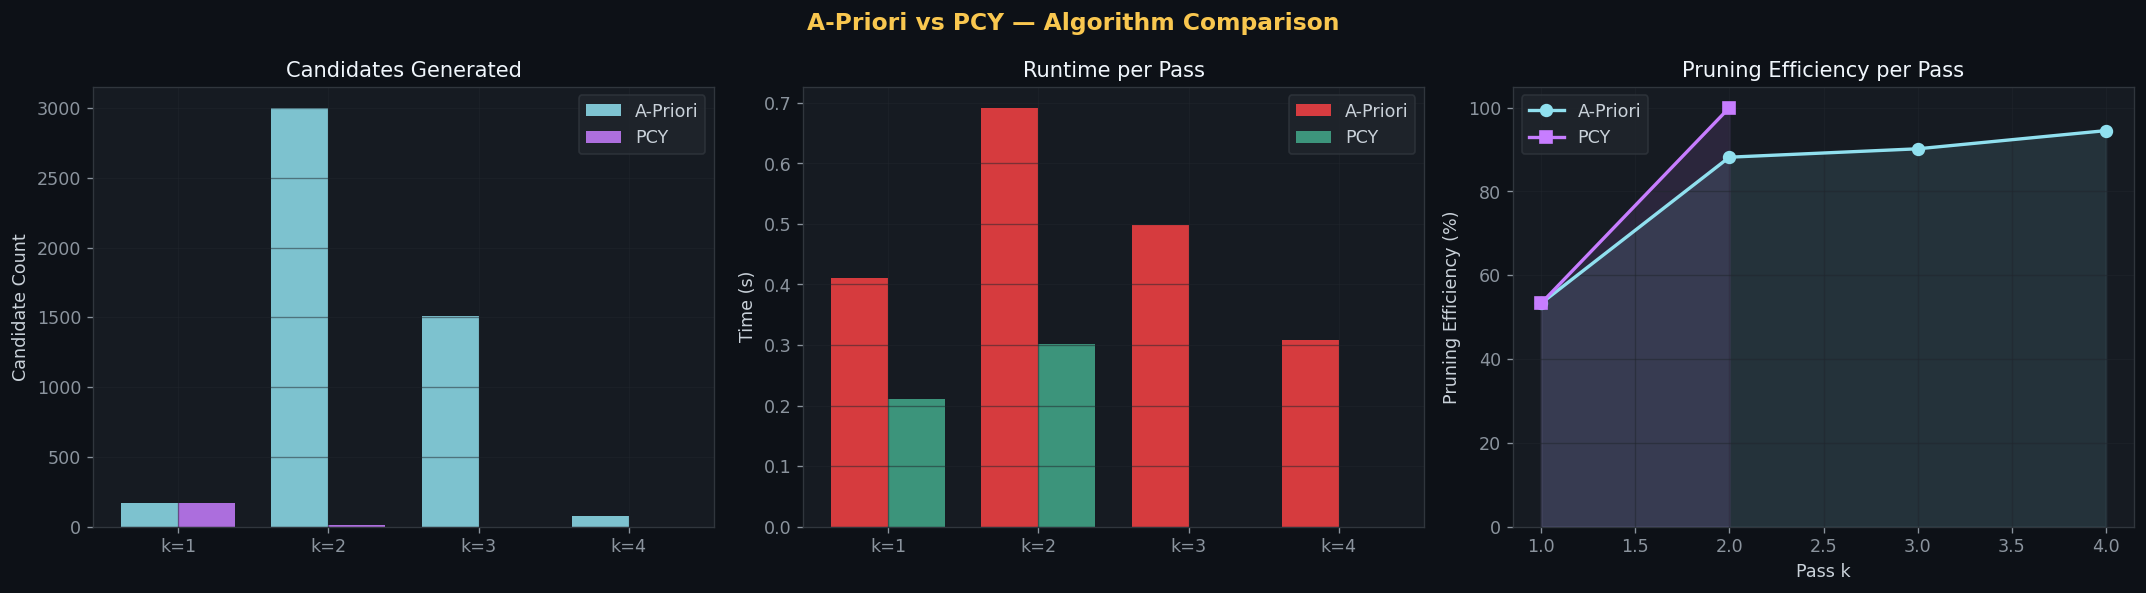

Saved: figures/fig3_algorithm_comparison.png

PCY Pass-2 candidate savings over A-Priori: 99.6%


In [13]:
ap_stats = pd.DataFrame(apriori.stats)
pcy_stats = pd.DataFrame(pcy.stats)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('A-Priori vs PCY — Algorithm Comparison',
             fontsize=14, fontweight='bold', color=ACCENT1)

ks_ap = ap_stats['k'].values
ks_pcy = pcy_stats['k'].values
width = 0.38

# (1) Candidates generated
ax = axes[0]
x = np.arange(len(ks_ap))
bars1 = ax.bar(x - width / 2, ap_stats['candidates'], width, label='A-Priori', color=ACCENT2, alpha=0.85)
bars2 = ax.bar(x + width / 2, pcy_stats['candidates'].reindex(range(len(ks_ap)), fill_value=0),
               width, label='PCY', color=ACCENT5, alpha=0.85)
ax.set_xticks(x);
ax.set_xticklabels([f'k={k}' for k in ks_ap])
ax.set_ylabel('Candidate Count');
ax.set_title('Candidates Generated')
ax.legend()

# (2) Runtime per pass
ax = axes[1]
ap_times = [apriori.timing.get(k, 0) for k in ks_ap]
pcy_times = [pcy.timing.get(k, 0) for k in ks_ap]
ax.bar(x - width / 2, ap_times, width, label='A-Priori', color=ACCENT3, alpha=0.85)
ax.bar(x + width / 2, pcy_times, width, label='PCY', color=ACCENT4, alpha=0.85)
ax.set_xticks(x);
ax.set_xticklabels([f'k={k}' for k in ks_ap])
ax.set_ylabel('Time (s)');
ax.set_title('Runtime per Pass')
ax.legend()

# (3) Prune efficiency (%)
ax = axes[2]
ap_pct = 100 * ap_stats['pruned'] / ap_stats['candidates'].clip(lower=1)
pcy_pct = 100 * pcy_stats['pruned'] / pcy_stats['candidates'].clip(lower=1)
ax.plot(ks_ap, ap_pct.values, 'o-', lw=2, color=ACCENT2, label='A-Priori', ms=7)
ax.plot(ks_pcy, pcy_pct.values, 's-', lw=2, color=ACCENT5, label='PCY', ms=7)
ax.fill_between(ks_ap, ap_pct.values, alpha=0.12, color=ACCENT2)
ax.fill_between(ks_pcy, pcy_pct.values, alpha=0.12, color=ACCENT5)
ax.set_xlabel('Pass k');
ax.set_ylabel('Pruning Efficiency (%)')
ax.set_title('Pruning Efficiency per Pass');
ax.legend()
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('figures/fig3_algorithm_comparison.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Saved: figures/fig3_algorithm_comparison.png')
print(f'\nPCY Pass-2 candidate savings over A-Priori: {pcy.pcy_savings_pct:.1f}%')

## Association Rules with 6 Interestingness Metrics

In [14]:
def mine_rules(frequent_itemsets, n_tx, min_conf=0.2, min_lift=1.0):
    """
    Compute 6 interestingness metrics for every valid rule:
      1. Support       = P(A ∪ B)
      2. Confidence    = P(B|A) = P(A∪B)/P(A)
      3. Lift          = Confidence / P(B)  [>1 positive, <1 negative correlation]
      4. Conviction    = (1 - P(B)) / (1 - Confidence)  [∞ for perfect rules]
      5. Leverage      = P(A∪B) - P(A)·P(B)  [0 = independent]
      6. Kulczynski    = 0.5·(P(B|A) + P(A|B))  [symmetric, range [0,1]]
    """
    sup_map = {}
    for d in frequent_itemsets.values():
        for iset, cnt in d.items():
            sup_map[iset] = cnt / n_tx

    rules = []
    for k, d in frequent_itemsets.items():
        if k < 2: continue
        for iset, cnt in d.items():
            sup_iset = cnt / n_tx
            for ant_size in range(1, k):
                for ant_tuple in combinations(iset, ant_size):
                    ant = frozenset(ant_tuple)
                    cons = iset - ant
                    sup_ant = sup_map.get(ant, 0)
                    sup_cons = sup_map.get(cons, 0)
                    if sup_ant == 0: continue
                    conf = sup_iset / sup_ant
                    if conf < min_conf: continue
                    lift = conf / sup_cons if sup_cons > 0 else 0
                    if lift < min_lift: continue
                    conviction = ((1 - sup_cons) / (1 - conf)
                                  if conf < 1 else float('inf'))
                    leverage = sup_iset - sup_ant * sup_cons
                    # Reverse conf for Kulczynski
                    rev_conf = sup_iset / sup_cons if sup_cons > 0 else 0
                    kulc = 0.5 * (conf + rev_conf)
                    rules.append({
                        'antecedent': ', '.join(sorted(ant)),
                        'consequent': ', '.join(sorted(cons)),
                        'ant_size': ant_size,
                        'cons_size': len(cons),
                        'support': round(sup_iset, 5),
                        'confidence': round(conf, 5),
                        'lift': round(lift, 5),
                        'conviction': round(min(conviction, 999.0), 5),
                        'leverage': round(leverage, 6),
                        'kulczynski': round(kulc, 5),
                    })

    df = pd.DataFrame(rules)
    if df.empty: return df
    return df.sort_values('lift', ascending=False).reset_index(drop=True)


MIN_CONFIDENCE = 0.2
rules_df = mine_rules(apriori.frequent_itemsets, n_transactions,
                      min_conf=MIN_CONFIDENCE, min_lift=1.0)

print(f'Rules generated : {len(rules_df):,}')
if not rules_df.empty:
    for col in ['support', 'confidence', 'lift', 'conviction', 'leverage', 'kulczynski']:
        print(f'  {col:15s}: mean={rules_df[col].mean():.4f}, '
              f'max={rules_df[col].max():.4f}')
    print('\nTop-10 rules by lift:')
    display_cols = ['antecedent', 'consequent', 'support', 'confidence', 'lift', 'conviction', 'kulczynski']
    print(rules_df[display_cols].head(10).to_string(index=False))

Rules generated : 858
  support        : mean=0.0426, max=0.1914
  confidence     : mean=0.3660, max=0.6569
  lift           : mean=1.2078, max=1.6669
  conviction     : mean=1.1087, max=1.5790
  leverage       : mean=0.0066, max=0.0209
  kulczynski     : mean=0.2593, max=0.4629

Top-10 rules by lift:
                              antecedent                   consequent  support  confidence    lift  conviction  kulczynski
                     sausage, whole milk other vegetables, rolls/buns  0.02617     0.24460 1.66690     1.12955     0.21146
                     rolls/buns, sausage other vegetables, whole milk  0.02617     0.31776 1.66034     1.18524     0.22724
                      rolls/buns, yogurt other vegetables, whole milk  0.03438     0.30876 1.61331     1.16980     0.24419
                other vegetables, yogurt       rolls/buns, whole milk  0.03438     0.28571 1.60016     1.15003     0.23912
               other vegetables, sausage       rolls/buns, whole milk  0.02617    